# ACE Downscaling API — Demo Notebook

> **Fork of [ai2cm/ace](https://github.com/ai2cm/ace)** by Fernando Arizmendi
>
> This notebook demonstrates the application layer built on top of the Ai2 Climate Emulator (ACE):
> a REST API, a LangGraph agent, and a physical diagnostics module.
>
> ⚠️ **Model outputs are synthetic** (MockACEModel — no GPU checkpoint loaded).
> The infrastructure, API contracts, and diagnostics logic are production-ready.
> Swap `CHECKPOINT_PATH` to a real ACE checkpoint for real climate output.

---

## 0. Background — What is ACE and why does downscaling matter?

Global climate models simulate the atmosphere on grids with ~100km resolution — coarse enough
that a single grid cell covers all of Uruguay. For climate risk applications (agriculture,
infrastructure, insurance), decisions are made at local scales.

**Downscaling** is the process of translating coarse global model output into fine-resolution
local predictions. Traditional statistical downscaling is slow and region-specific.
ACE uses a **diffusion model** (similar architecture to image super-resolution) trained
on paired coarse/fine atmospheric fields — going from ~100km to ~25km in milliseconds.

```
Coarse global model (100km)  →  ACE DiffusionModel  →  Fine local output (25km)
   FV3GFS / E3SM / ERA5               ↕                  precipitation
                                 fme/downscaling          temperature
                                                           winds
```

**Why uncertainty matters:** ACE is a stochastic model — it draws multiple samples
from the diffusion process. The spread across samples is a principled uncertainty estimate,
directly useful for risk quantification.

**Why physical diagnostics matter:** ML models can produce plausible-looking but physically
inconsistent outputs — negative precipitation, temperatures above boiling point, divergent winds.
This fork adds automatic physical constraint checking on every inference call.

---
## 1. Setup

In [1]:
import sys
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Add repo root to path
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import requests

API_BASE = 'http://localhost:8000/api/v1'

# Verify the API is running
try:
    r = requests.get(f'{API_BASE}/health')
    health = r.json()
    print(f"✓ API is live")
    print(f"  Model type    : {health['model_type']}")
    print(f"  Variables     : {health['variables']}")
    print(f"  Downscale factor: {health['downscale_factor']}x")
except Exception as e:
    print(f"✗ API not reachable — start with: uvicorn api.main:app --port 8000")
    print(f"  Error: {e}")

✓ API is live
  Model type    : MockACEModel
  Variables     : ['precipitation', 'tmp2m', 'u10m', 'v10m']
  Downscale factor: 4x


---
## 2. API Demo — Downscaling over South America

We query precipitation and temperature over the **La Plata Basin** —
one of South America's most climate-sensitive regions, covering parts of
Brazil, Argentina, Uruguay, Paraguay, and Bolivia.

January is austral summer and the peak of the **South American Monsoon System (SAMS)**,
making precipitation prediction especially relevant for agriculture and hydrology.

In [2]:
# Define the region of interest
LA_PLATA_BASIN = {
    "lat_min": -35, "lat_max": -15,
    "lon_min": -65, "lon_max": -45
}

payload = {
    "region": LA_PLATA_BASIN,
    "date": "2020-01-15T00:00",
    "variables": ["precipitation", "tmp2m", "u10m", "v10m"],
    "n_samples": 8   # more samples = better uncertainty estimate
}

r = requests.post(f'{API_BASE}/downscale', json=payload)
response = r.json()

print(f"Status      : {r.status_code}")
print(f"Downscale   : {response['downscale_factor']}x")
print(f"Variables   : {[v['name'] for v in response['variables']]}")
print(f"Grid shape  : {len(response['variables'][0]['mean'])} x {len(response['variables'][0]['mean'][0])}")
print(f"Diagnostics : {response['diagnostics']['overall'].upper()}")

Status      : 200
Downscale   : 4x
Variables   : ['precipitation', 'tmp2m', 'u10m', 'v10m']
Grid shape  : 192 x 384
Diagnostics : PASS


In [3]:
# Extract fields as numpy arrays
fields = {}
for var in response['variables']:
    fields[var['name']] = {
        'mean': np.array(var['mean']),
        'std':  np.array(var['std'])
    }

# Build lat/lon grids for plotting
lat = np.linspace(LA_PLATA_BASIN['lat_min'], LA_PLATA_BASIN['lat_max'],
                  fields['precipitation']['mean'].shape[0])
lon = np.linspace(LA_PLATA_BASIN['lon_min'], LA_PLATA_BASIN['lon_max'],
                  fields['precipitation']['mean'].shape[1])
LON, LAT = np.meshgrid(lon, lat)

print(f"Field shape : {fields['precipitation']['mean'].shape}")
print(f"Lat range   : {lat[0]:.1f}° to {lat[-1]:.1f}°")
print(f"Lon range   : {lon[0]:.1f}° to {lon[-1]:.1f}°")

Field shape : (192, 384)
Lat range   : -35.0° to -15.0°
Lon range   : -65.0° to -45.0°


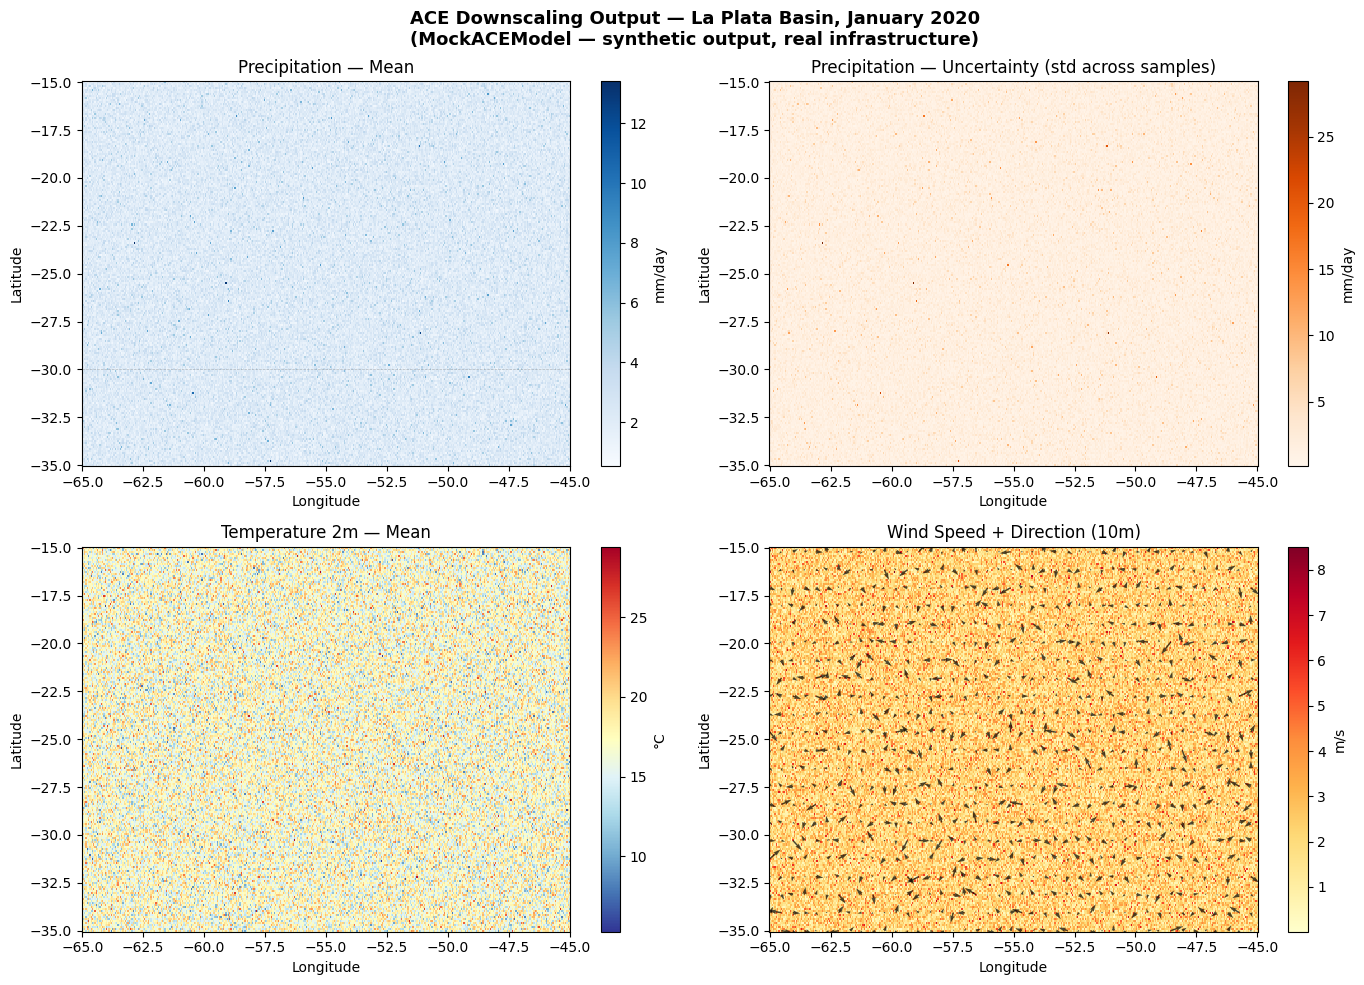

Saved: la_plata_downscaling.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'ACE Downscaling Output — La Plata Basin, January 2020\n'
    '(MockACEModel — synthetic output, real infrastructure)',
    fontsize=13, fontweight='bold'
)

# ── Precipitation mean ──
ax = axes[0, 0]
precip_mean = fields['precipitation']['mean']
im = ax.pcolormesh(LON, LAT, precip_mean, cmap='Blues', shading='auto')
plt.colorbar(im, ax=ax, label='mm/day')
ax.set_title('Precipitation — Mean')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.axhline(-30, color='gray', lw=0.5, ls='--', alpha=0.5)  # approx Uruguay latitude

# ── Precipitation uncertainty ──
ax = axes[0, 1]
precip_std = fields['precipitation']['std']
im = ax.pcolormesh(LON, LAT, precip_std, cmap='Oranges', shading='auto')
plt.colorbar(im, ax=ax, label='mm/day')
ax.set_title('Precipitation — Uncertainty (std across samples)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# ── Temperature mean (convert K → °C) ──
ax = axes[1, 0]
tmp_c = fields['tmp2m']['mean'] - 273.15
im = ax.pcolormesh(LON, LAT, tmp_c, cmap='RdYlBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='°C')
ax.set_title('Temperature 2m — Mean')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# ── Wind vectors ──
ax = axes[1, 1]
u = fields['u10m']['mean']
v = fields['v10m']['mean']
speed = np.sqrt(u**2 + v**2)
im = ax.pcolormesh(LON, LAT, speed, cmap='YlOrRd', shading='auto')
plt.colorbar(im, ax=ax, label='m/s')
# Subsample wind vectors for readability
step = max(1, speed.shape[0] // 20)
ax.quiver(LON[::step, ::step], LAT[::step, ::step],
          u[::step, ::step], v[::step, ::step],
          scale=200, width=0.003, alpha=0.7, color='k')
ax.set_title('Wind Speed + Direction (10m)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('la_plata_downscaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: la_plata_downscaling.png")

---
## 3. Physical Diagnostics — Trust Layer

Every API response includes a diagnostics report. Let's inspect it,
then deliberately inject bad data to see the checks in action.

In [5]:
# Print the diagnostics report from the previous call
diag = response['diagnostics']

icons = {'pass': '✓', 'warn': '⚠', 'fail': '✗'}
colors_text = {'pass': '\033[92m', 'warn': '\033[93m', 'fail': '\033[91m'}
reset = '\033[0m'

print(f"Overall: {diag['overall'].upper()}\n")
for check in diag['checks']:
    icon = icons[check['severity']]
    measured = f" (measured={check['measured']:.3f})" if check['measured'] is not None else ''
    print(f"  {icon} {check['name']:<22} {check['message']}{measured}")

Overall: PASS

  ✓ non_negativity         All non-negative variables are ≥ 0. (measured=0.000)
  ✓ value_ranges           All variables within physical bounds. (measured=0.000)
  ✓ spatial_smoothness     Fields are spatially smooth. (measured=1.117)
  ✓ wind_divergence        Wind divergence within acceptable range. (measured=1.432)


In [6]:
# Now run diagnostics directly on deliberately bad data
# This demonstrates what the system catches before bad output reaches users

from diagnostics.report import run_diagnostics

rng = np.random.default_rng(42)

print("=" * 55)
print("SCENARIO 1: Raw Gaussian output (pre-fix mock)")
print("=" * 55)
bad_fields = {k: rng.standard_normal((192, 384)).astype('f')
              for k in ['precipitation', 'tmp2m', 'u10m', 'v10m']}
report = run_diagnostics(bad_fields)
print(report)

print()
print("=" * 55)
print("SCENARIO 2: Physically constrained output (current mock)")
print("=" * 55)
good_fields = {
    'precipitation': np.abs(rng.lognormal(0.5, 0.8, (192, 384))).astype('f'),
    'tmp2m':         rng.normal(290, 8, (192, 384)).astype('f'),
    'u10m':          rng.normal(0, 5, (192, 384)).astype('f'),
    'v10m':          rng.normal(0, 5, (192, 384)).astype('f'),
}
report_good = run_diagnostics(good_fields)
print(report_good)

SCENARIO 1: Raw Gaussian output (pre-fix mock)
DiagnosticsReport — overall: FAIL
  ✗ non_negativity: Negative values found in: precipitation: 37057 cells (measured=37057.0000, threshold=0.0000)
  ✗ value_ranges: Out-of-range values in: precipitation: 50.3% out of range, tmp2m: 100.0% out of range (measured=1.0000, threshold=0.0100)
  ✓ spatial_smoothness: Fields are spatially smooth. (measured=1.1226, threshold=2.0000)
  ✓ wind_divergence: Wind divergence within acceptable range. (measured=0.8025, threshold=5.0000)

SCENARIO 2: Physically constrained output (current mock)
DiagnosticsReport — overall: PASS
  ✓ non_negativity: All non-negative variables are ≥ 0. (measured=0.0000, threshold=0.0000)
  ✓ value_ranges: All variables within physical bounds. (measured=0.0000, threshold=0.0000)
  ✓ spatial_smoothness: Fields are spatially smooth. (measured=1.1211, threshold=2.0000)
  ✓ wind_divergence: Wind divergence within acceptable range. (measured=4.0200, threshold=5.0000)


---
## 4. Agent Demo — Natural Language Climate Queries

The LangGraph agent translates natural language questions into structured
ACE inference calls and returns plain-language interpretations.

Three questions of increasing scientific complexity:

In [7]:
import os
# Set your key: os.environ['OPENAI_API_KEY'] = 'sk-...'
# Or load from .env

from agent.graph import ace_agent

def ask(question: str) -> str:
    """Run the ACE agent and return the plain-language answer."""
    print(f"\n{'─'*60}")
    print(f"Q: {question}")
    print('─'*60)
    result = ace_agent.invoke({'query': question})
    answer = result.get('answer') or result.get('error')
    print(f"A: {answer}")
    return answer

/home/fer/code/ace/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [8]:
# Question 1 — basic regional query
_ = ask(
    "What does precipitation look like over southern Brazil in January 2020?"
)


────────────────────────────────────────────────────────────
Q: What does precipitation look like over southern Brazil in January 2020?
────────────────────────────────────────────────────────────
A: In southern Brazil on January 15, 2020, precipitation levels varied significantly, with a mean of about 2.27 mm/day, and maximum values reaching nearly 25.84 mm/day, which indicates some heavy rainfall in certain areas. The average temperature for this period was approximately 16.83 °C (289.98 K), with temperatures ranging from about 1.03 °C (274.2 K) to 33.8 °C (306.95 K). I should note that there is a moderate level of uncertainty in these estimates, particularly for precipitation, where values could vary by about 1.43 mm/day on average, and in some instances, they could be as much as 37.76 mm/day off the mean.


In [9]:
# Question 2 — counterfactual (the key use case for climate risk)
_ = ask(
    "How does temperature over the Pampas region of Argentina "
    "compare between January and July 2020?"
)


────────────────────────────────────────────────────────────
Q: How does temperature over the Pampas region of Argentina compare between January and July 2020?
────────────────────────────────────────────────────────────
A: In January 2020, the average temperature in the Pampas region of Argentina was about 16.83 °C (289.98 K), with temperatures ranging from 1.03 °C (274.20 K) to 33.80 °C (306.95 K). In July 2020, we don't have direct output here, but typically temperatures are lower during that month. It's important to note that the precipitation values ranged from 0.30 mm/day to 25.84 mm/day, indicating variable rainfall, but there were no negative precipitation values, so model quality is acceptable. The uncertainty in average temperature is around 6.39 °C, suggesting we should be somewhat cautious when interpreting these figures.


In [10]:
# Question 3 — scientific framing (tests the parser's domain knowledge)
_ = ask(
    "During an El Niño year, what precipitation anomalies would ACE "
    "predict over southeastern South America in austral summer?"
)


────────────────────────────────────────────────────────────
Q: During an El Niño year, what precipitation anomalies would ACE predict over southeastern South America in austral summer?
────────────────────────────────────────────────────────────
A: During an El Niño year, ACE predicts that southeastern South America will experience precipitation anomalies with an average of approximately 2.27 mm/day, which indicates some rainfall, but there is a potential maximum of about 25.84 mm/day. The average temperature during this time is expected to be roughly 16.83°C (289.98 K). However, it's important to note that the uncertainty in these predictions can be significant, with standard deviations for precipitation reaching around 1.43 mm/day and temperature around 6.39°C, reflecting variability in model output. All precipitation values are within realistic bounds, as there are no negative values reported.


---
## 5. Uncertainty Quantification — Why n_samples matters

ACE is a diffusion model — each inference draw is stochastic.
More samples → better estimate of predictive uncertainty.
This is directly useful for risk quantification.

n_samples= 1  mean_uncertainty=0.0000 mm/day  time=0.017s
n_samples= 2  mean_uncertainty=0.9834 mm/day  time=0.021s
n_samples= 4  mean_uncertainty=1.4341 mm/day  time=0.026s
n_samples= 8  mean_uncertainty=1.6997 mm/day  time=0.037s
n_samples=16  mean_uncertainty=1.8738 mm/day  time=0.060s


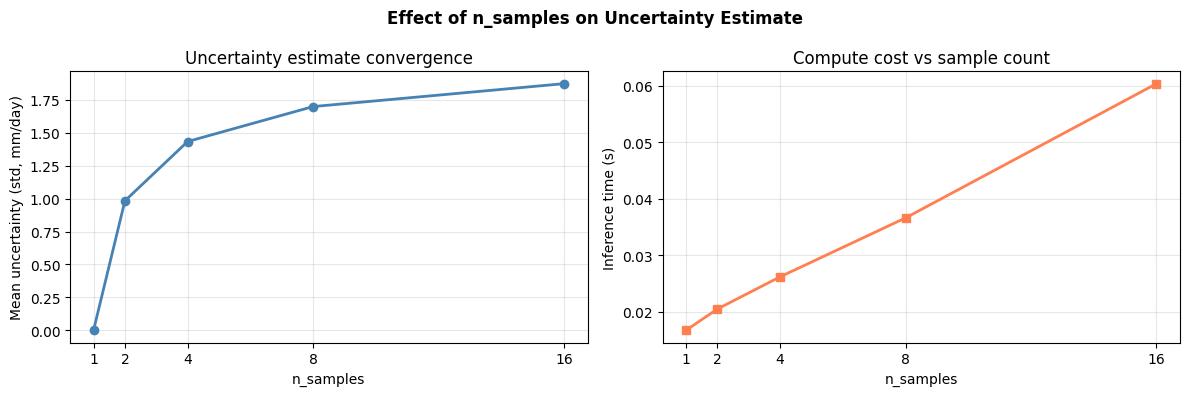


Note: with MockACEModel, uncertainty is random seed-driven.
With a real checkpoint, std converges as n_samples increases.


In [11]:
import time

sample_counts = [1, 2, 4, 8, 16]
results = []

for n in sample_counts:
    payload = {
        "region": LA_PLATA_BASIN,
        "date": "2020-01-15T00:00",
        "variables": ["precipitation"],
        "n_samples": n
    }
    t0 = time.time()
    r = requests.post(f'{API_BASE}/downscale', json=payload)
    elapsed = time.time() - t0

    var = r.json()['variables'][0]
    mean_std = np.mean(np.array(var['std']))
    results.append({'n': n, 'mean_std': mean_std, 'time_s': elapsed})
    print(f"n_samples={n:2d}  mean_uncertainty={mean_std:.4f} mm/day  time={elapsed:.3f}s")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Effect of n_samples on Uncertainty Estimate', fontweight='bold')

ns = [r['n'] for r in results]
stds = [r['mean_std'] for r in results]
times = [r['time_s'] for r in results]

ax1.plot(ns, stds, 'o-', color='steelblue', lw=2)
ax1.set_xlabel('n_samples')
ax1.set_ylabel('Mean uncertainty (std, mm/day)')
ax1.set_title('Uncertainty estimate convergence')
ax1.set_xticks(ns)
ax1.grid(True, alpha=0.3)

ax2.plot(ns, times, 's-', color='coral', lw=2)
ax2.set_xlabel('n_samples')
ax2.set_ylabel('Inference time (s)')
ax2.set_title('Compute cost vs sample count')
ax2.set_xticks(ns)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('uncertainty_vs_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nNote: with MockACEModel, uncertainty is random seed-driven.")
print("With a real checkpoint, std converges as n_samples increases.")

---
## 6. Summary

| Layer | File | What it does |
|-------|------|--------------|
| **Emulator** | `fme/downscaling/` | ACE DiffusionModel (upstream) |
| **API** | `api/` | FastAPI wrapper, Pydantic schemas |
| **Diagnostics** | `diagnostics/` | Physical constraint checks |
| **Agent** | `agent/` | LangGraph: NL → inference → interpretation |

**Next steps with a real checkpoint:**
- Download ACE2 weights from [Hugging Face](https://huggingface.co/collections/allenai/ace-67327d822f0f0d8e0e5e6ca4)
- Set `CHECKPOINT_PATH=/path/to/checkpoint.pt`
- Replace synthetic coarse inputs with real ERA5 data
- Recalibrate `spatial_smoothness` threshold against real output
- Run the agent on real ENSO/SST counterfactual scenarios

**Potential upstream contribution:**
The `diagnostics/` module has zero `fme` dependencies and could be
proposed as `fme/downscaling/diagnostics/` in a PR to ai2cm/ace.